<div style="text-align: center; padding: 40px; border: 1px solid #e0e0e0; border-radius: 20px; box-shadow: 0 4px 15px rgba(0,0,0,0.05);">
    <h1 style="font-family: 'Georgia', serif; font-size: 2.8em; color: #2c3e50; line-height: 1.1;">
        Fair Conformal Prediction for <br> Individuals and Subgroups
    </h1>
    <div style="margin: 20px auto; width: 60px; height: 3px; background-color: #e74c3c;"></div>
    <h2 style="font-family: 'Helvetica', sans-serif; font-weight: 400; color: #7f8c8d; text-transform: uppercase; letter-spacing: 2px; font-size: 1.1em;">
        In Natural and Adversarial Settings
    </h2>
    <p style="font-family: 'Helvetica', sans-serif; color: #34495e; font-weight: bold; margin-top: 15px;">
        Theoretical Guarantees & Impossibility Results
    </p>
</div>

In [18]:
import torch

from datasets.loader import *
from models.mlp import *
from models.train import *
from attacks.pgd_cf import *
from experiments.run_natural import run_natural_experiment
from experiments.run_A1 import run_counterfactual_experiment_A1
from experiments.run_A2 import run_counterfactual_experiment_A2
from plots.plotting import *
from conformal.metrics import *

device = "cuda" if torch.cuda.is_available() else "cpu"

# ===== CONFIG ===== #

#["adult", "compas", "german", "student", "arrhythmia", "bank"]

dataset_name = "student"

alpha = 0.1
agg = "mean"

eps = 0.25

lambd = 0.6
eps_values = [0., 0.05, 0.1, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.5]

# ===== DATA ===== #

dataset = load_dataset(dataset_name)

# ===== MODEL ===== #

model = build_model(dataset)
model = train_model(model, dataset, epochs=100, batch_size=128, lr=1e-3, C = 1, device=device)

# ===== EXPERIMENTS ===== #

# NATURAL #
results_natural = run_natural_experiment(model, dataset, dataset.X_cal, dataset.X_test, alpha, agg)

print_table(
    {"C": results_natural["vanilla"],
     "C_EQ": results_natural["EQ"],
     "C_EQ_k_a": results_natural["EQ_ka"],
     "C_EQ_max": results_natural["EQ_max"]},
    "NATURAL SETTING")

# A_1 #

X_cal_adv_A1, X_cal_cf_adv_A1 = generate_attacked_data(model, dataset.X_cal, dataset.y_cal, dataset.s_cal, dataset.s_index, eps, lambd)
X_test_adv_A1, X_test_cf_adv_A1 = generate_attacked_data(model, dataset.X_test, dataset.y_test, dataset.s_test, dataset.s_index, eps, lambd)

results_A1_adv = run_natural_experiment(model, dataset, dataset.X_cal, X_test_adv_A1, alpha, agg)
print_table(
    {"C": results_A1_adv["vanilla"],
     "C_EQ": results_A1_adv["EQ"],
     "C_EQ_k_a": results_A1_adv["EQ_ka"],
     "C_EQ_max": results_A1_adv["EQ_max"]},
    "A1 - ADVERSARIAL SETTING (NO DEFENCE)"
)

results_A1_percp = run_natural_experiment(model, dataset, X_cal_adv_A1, X_test_adv_A1, alpha, agg)
print_table(
    {"C": results_A1_percp["vanilla"],
     "C_EQ": results_A1_percp["EQ"],
     "C_EQ_k_a": results_A1_percp["EQ_ka"],
     "C_EQ_max": results_A1_percp["EQ_max"]},
    "A1 - ADVERSARIAL SETTING (WITH DEFENCE)"
)

# A2 #

# group 0 attack test
X_test_adv_A2_0, X_test_cf_adv_A2_0 = generate_attacked_data(model, dataset.X_test, dataset.y_test, dataset.s_test, dataset.s_index, eps, lambd, target_group = 0)

# group 1 attack test
X_test_adv_A2_1, X_test_cf_adv_A2_1 = generate_attacked_data(model, dataset.X_test, dataset.y_test, dataset.s_test, dataset.s_index, eps, lambd, target_group = 1)

# group 0 attack cal
X_cal_adv_A2_0, X_cal_cf_adv_A2_0 = generate_attacked_data(model, dataset.X_cal, dataset.y_cal, dataset.s_cal, dataset.s_index, eps, lambd, target_group = 0)

# group 1 attack cal
X_cal_adv_A2_1, X_cal_cf_adv_A2_1 = generate_attacked_data(model, dataset.X_cal, dataset.y_cal, dataset.s_cal, dataset.s_index, eps, lambd, target_group = 1)

# A2 #

# group 0 attack test
X_test_adv_A2_0, X_test_cf_adv_A2_0 = generate_attacked_data(model, dataset.X_test, dataset.y_test, dataset.s_test, dataset.s_index, eps, lambd, target_group = 0)

# group 1 attack test
X_test_adv_A2_1, X_test_cf_adv_A2_1 = generate_attacked_data(model, dataset.X_test, dataset.y_test, dataset.s_test, dataset.s_index, eps, lambd, target_group = 1)

# group 0 attack cal
X_cal_adv_A2_0, X_cal_cf_adv_A2_0 = generate_attacked_data(model, dataset.X_cal, dataset.y_cal, dataset.s_cal, dataset.s_index, eps, lambd, target_group = 0)

# group 1 attack cal
X_cal_adv_A2_1, X_cal_cf_adv_A2_1 = generate_attacked_data(model, dataset.X_cal, dataset.y_cal, dataset.s_cal, dataset.s_index, eps, lambd, target_group = 1)


results_A2_0_adv = run_natural_experiment(model, dataset, dataset.X_cal, X_test_adv_A2_0, alpha, agg)
print_table(
    {"C": results_A2_0_adv["vanilla"],
     "C_EQ": results_A2_0_adv["EQ"],
     "C_EQ_k_a": results_A2_0_adv["EQ_ka"],
     "C_EQ_max": results_A2_0_adv["EQ_max"]},
    "A2 0 - ADVERSARIAL SETTING (NO DEFENCE)"
)

results_A2_0_percp = run_natural_experiment(model, dataset, X_cal_adv_A2_0, X_test_adv_A2_0, alpha, agg)
print_table(
    {"C": results_A2_0_percp["vanilla"],
     "C_EQ": results_A2_0_percp["EQ"],
     "C_EQ_k_a": results_A2_0_percp["EQ_ka"],
     "C_EQ_max": results_A2_0_percp["EQ_max"]},
    "A2 0 - ADVERSARIAL SETTING (WITH DEFENCE)"
)

results_A2_1_adv = run_natural_experiment(model, dataset, dataset.X_cal, X_test_adv_A2_1, alpha, agg)
print_table(
    {"C": results_A2_1_adv["vanilla"],
     "C_EQ": results_A2_1_adv["EQ"],
     "C_EQ_k_a": results_A2_1_adv["EQ_ka"],
     "C_EQ_max": results_A2_1_adv["EQ_max"]},
    "A2 1 - ADVERSARIAL SETTING (NO DEFENCE)"
)

results_A2_1_percp = run_natural_experiment(model, dataset, X_cal_adv_A2_1, X_test_adv_A2_1, alpha, agg)
print_table(
    {"C": results_A2_1_percp["vanilla"],
     "C_EQ": results_A2_1_percp["EQ"],
     "C_EQ_k_a": results_A2_1_percp["EQ_ka"],
     "C_EQ_max": results_A2_1_percp["EQ_max"]},
    "A2 1 - ADVERSARIAL SETTING (WITH DEFENCE)"
)

Epoch 5/100 | Loss 0.7957
Epoch 10/100 | Loss 0.3983
Epoch 15/100 | Loss 0.3435
Epoch 20/100 | Loss 0.3129
Epoch 25/100 | Loss 0.2968
Epoch 30/100 | Loss 0.2822
Epoch 35/100 | Loss 0.2711
Epoch 40/100 | Loss 0.2578
Epoch 45/100 | Loss 0.2510
Epoch 50/100 | Loss 0.2492
Epoch 55/100 | Loss 0.2173
Epoch 60/100 | Loss 0.2238
Epoch 65/100 | Loss 0.2113
Epoch 70/100 | Loss 0.1904
Epoch 75/100 | Loss 0.1763
Epoch 80/100 | Loss 0.1636
Epoch 85/100 | Loss 0.1496
Epoch 90/100 | Loss 0.1825
Epoch 95/100 | Loss 0.1243
Epoch 100/100 | Loss 0.1170

Training finished

Train Accuracy: 0.953
Test  Accuracy: 0.853



Train Total Effect: 0 (0.00%)
Test Total Effect: 1 (0.64%)

===== NATURAL SETTING =====

--- C ---
Coverage     : G=0.92±0.04, F=0.95±0.04, M=0.89±0.07
Coverage CF  : G=0.92±0.04, F=0.89±0.07, M=0.95±0.04
Size         : G=1.26±0.07, F=1.27±0.09, M=1.29±0.11
Size CF      : G=1.26±0.07, F=1.26±0.10, M=1.27±0.09

--- C_EQ ---
Coverage     : G=0.92±0.04, F=0.95±0.04, M=0.89±0.07
Coverage CF  : 

## Adversarial Setting Plots

100%|██████████| 11/11 [00:15<00:00,  1.40s/it]


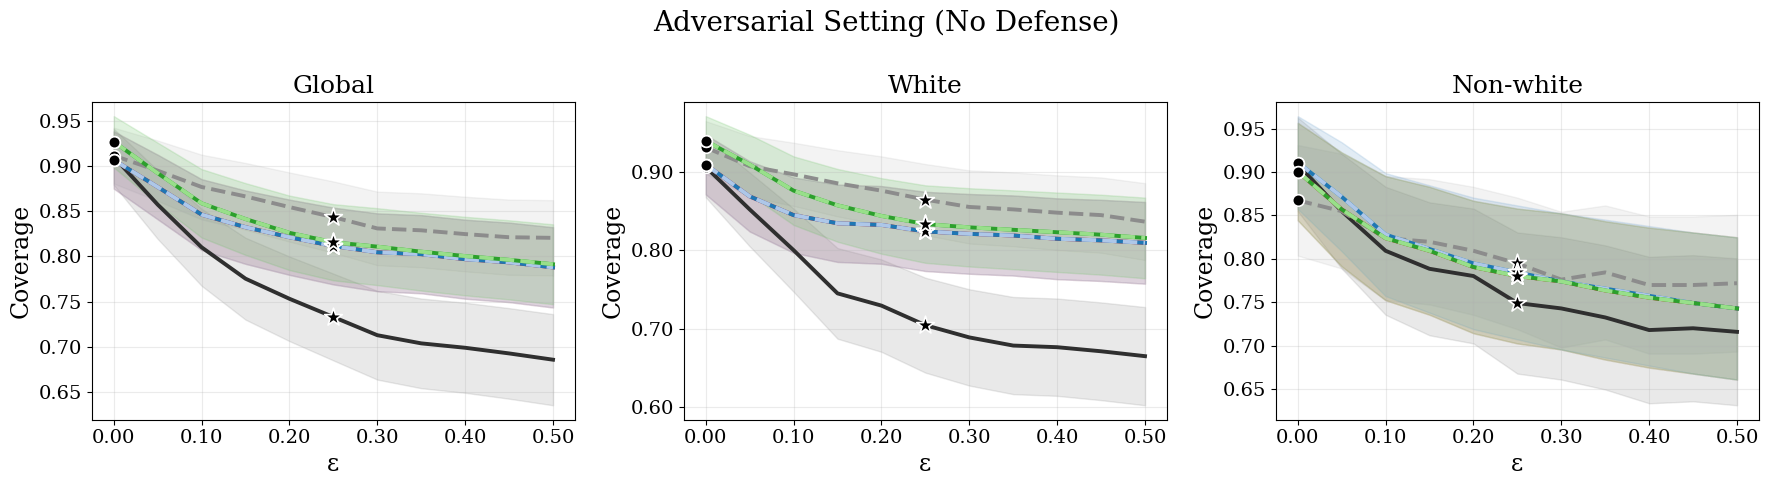

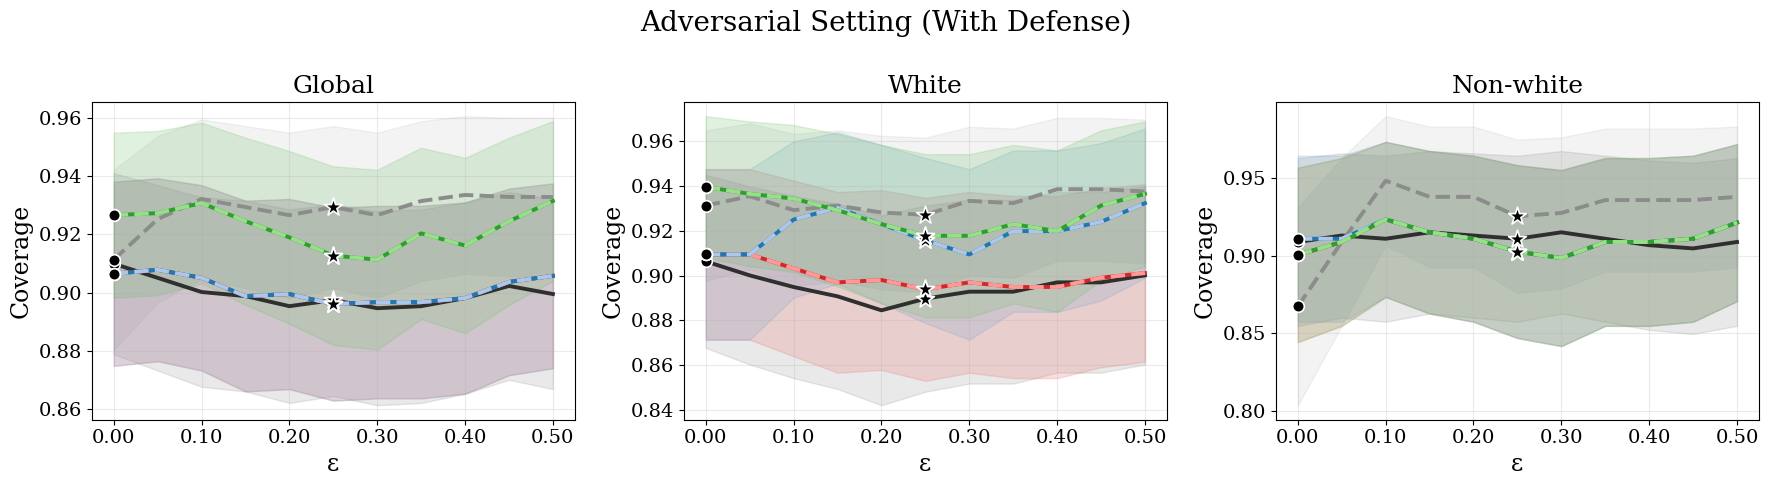

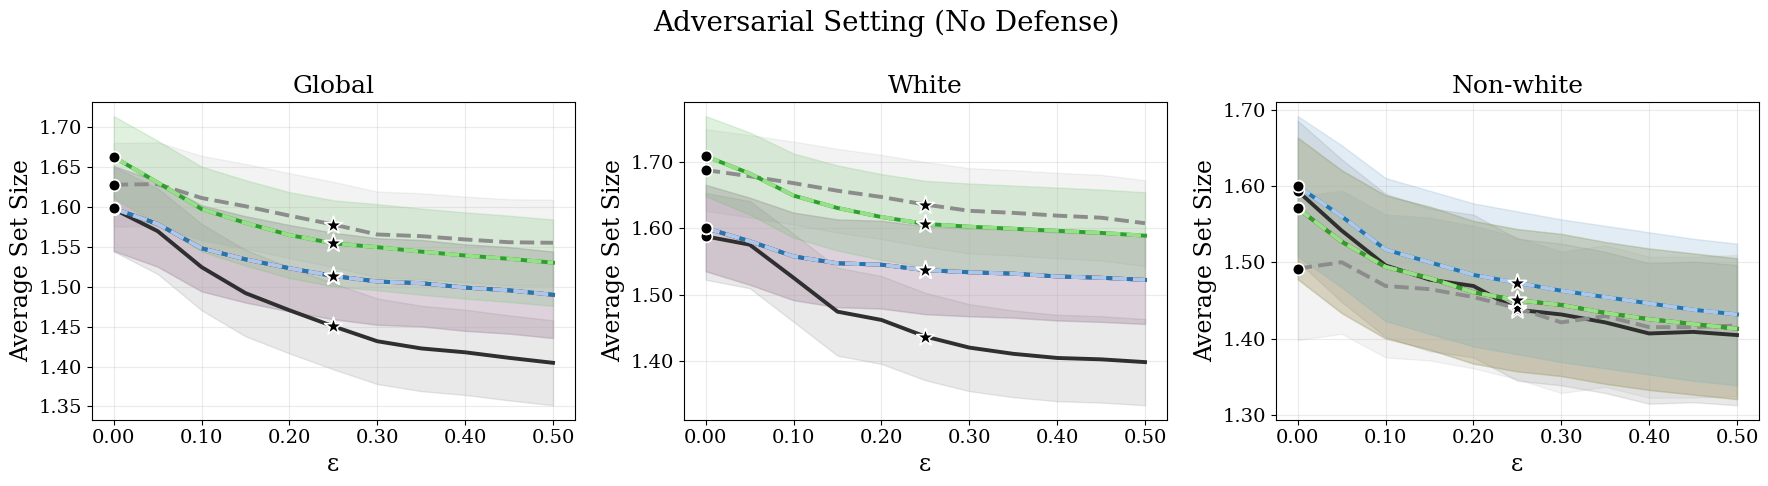

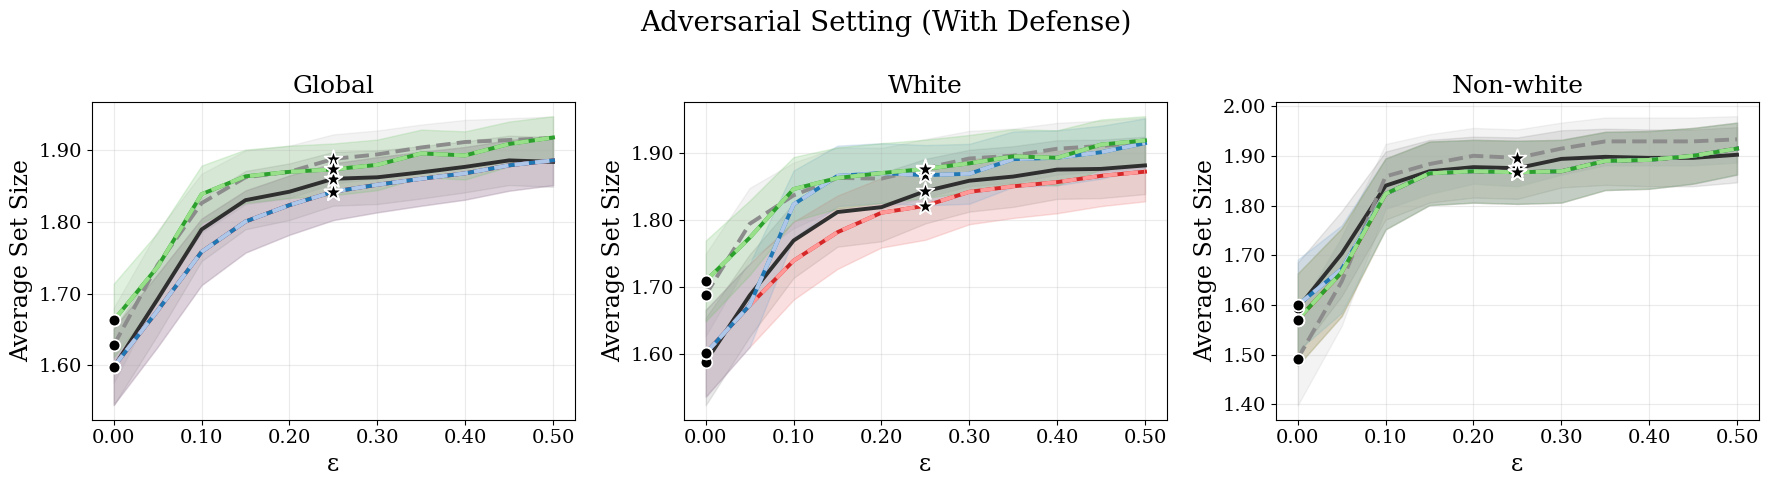

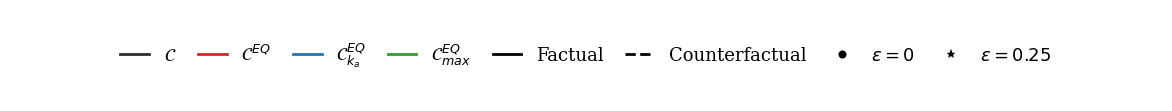

In [13]:
results = run_counterfactual_experiment_A1(model, dataset, eps_values, lambd=lambd, alpha=alpha, agg=agg)

plot_cp_coverage(results, 0.1, eps, dataset_name)
plot_cp_size(results, 0.1, eps, dataset_name)

add_global_legend(eps)

100%|██████████| 11/11 [00:15<00:00,  1.41s/it]


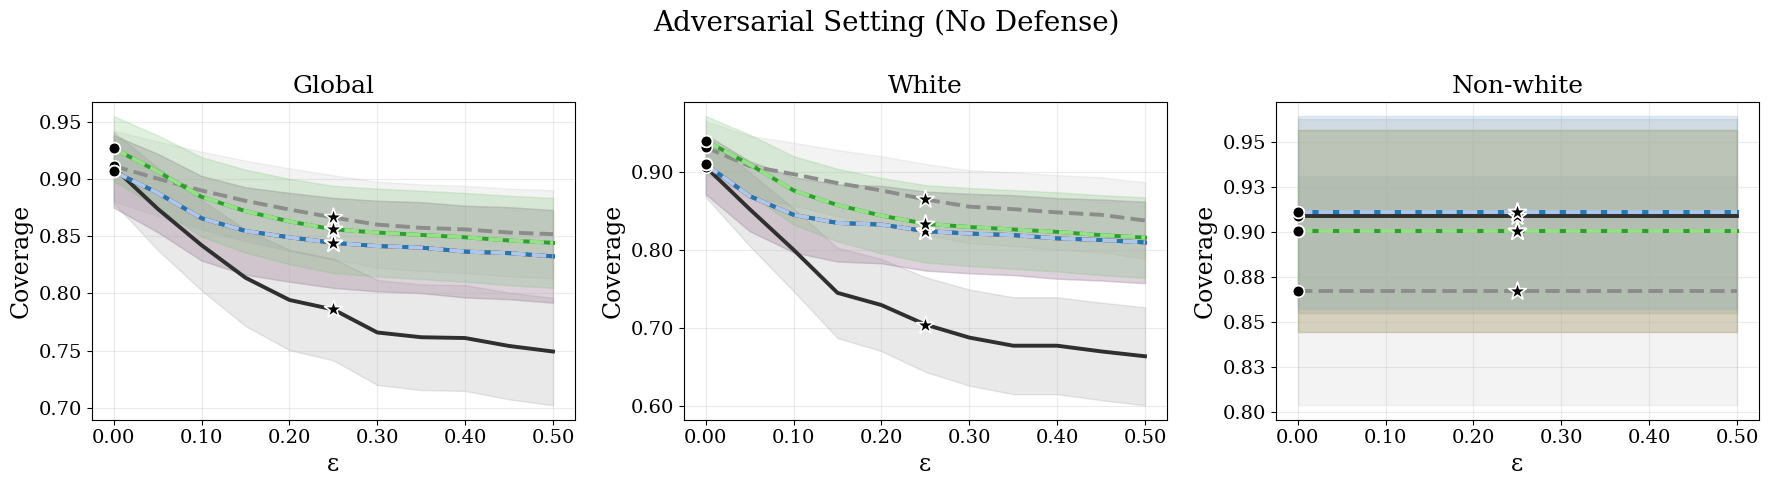

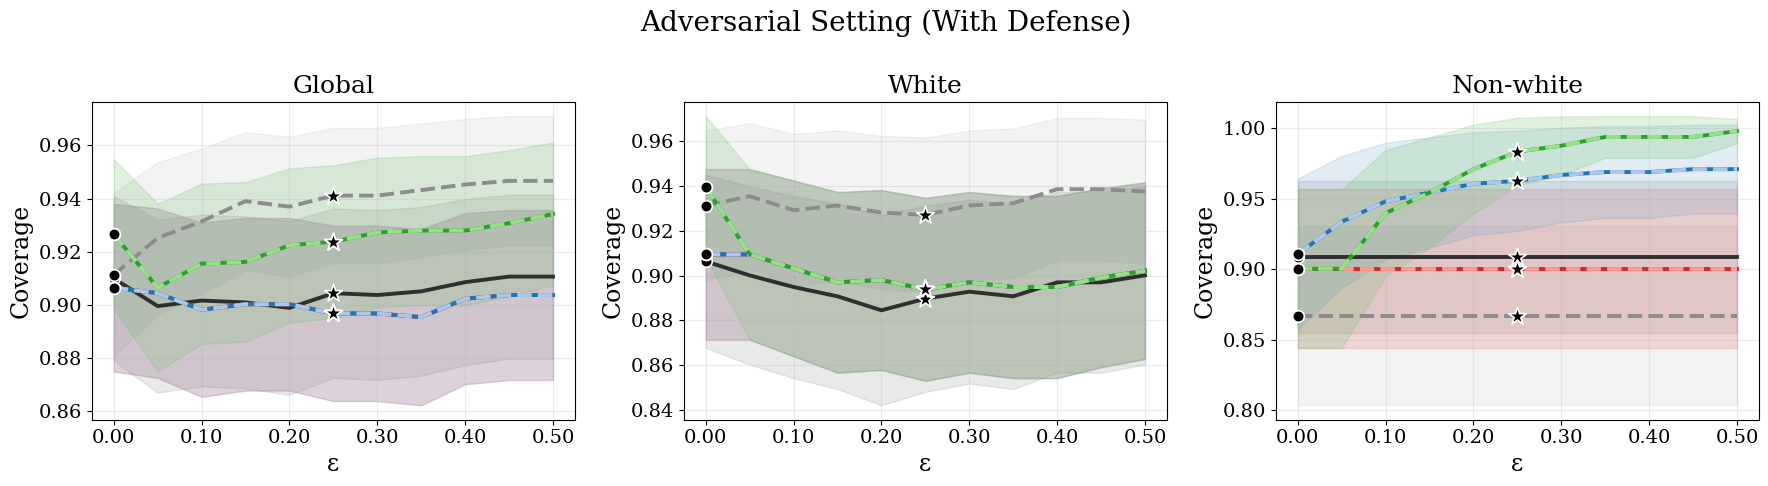

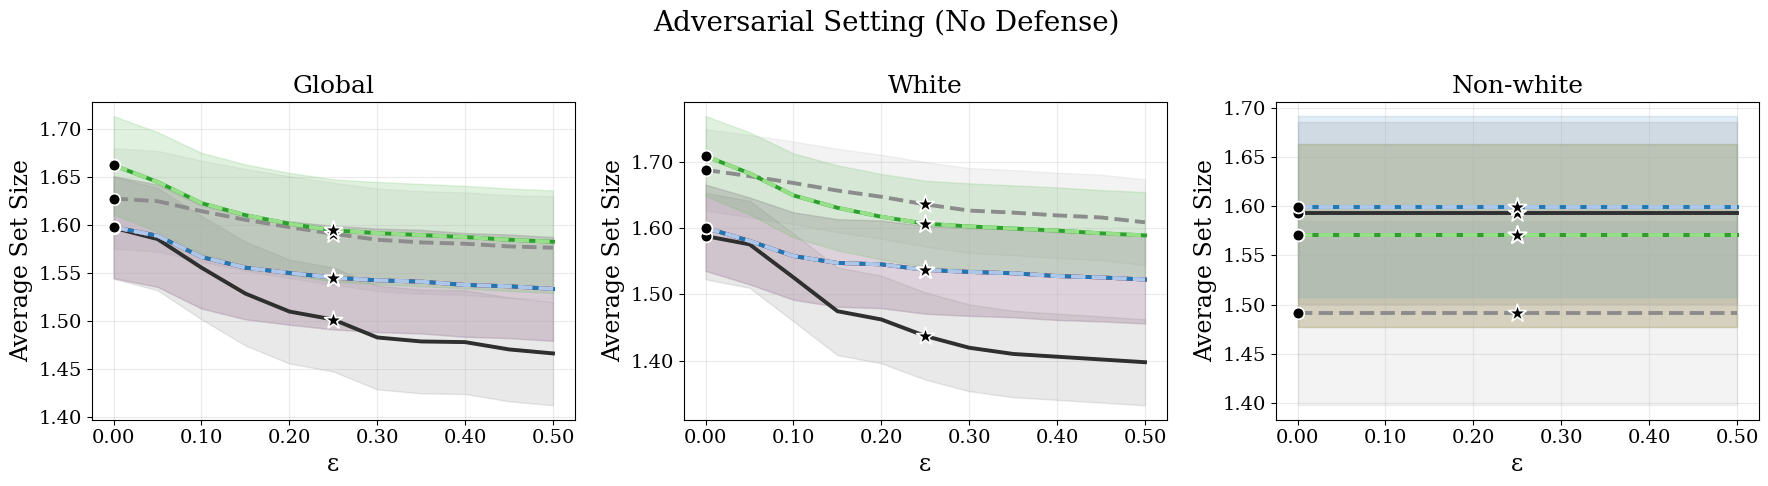

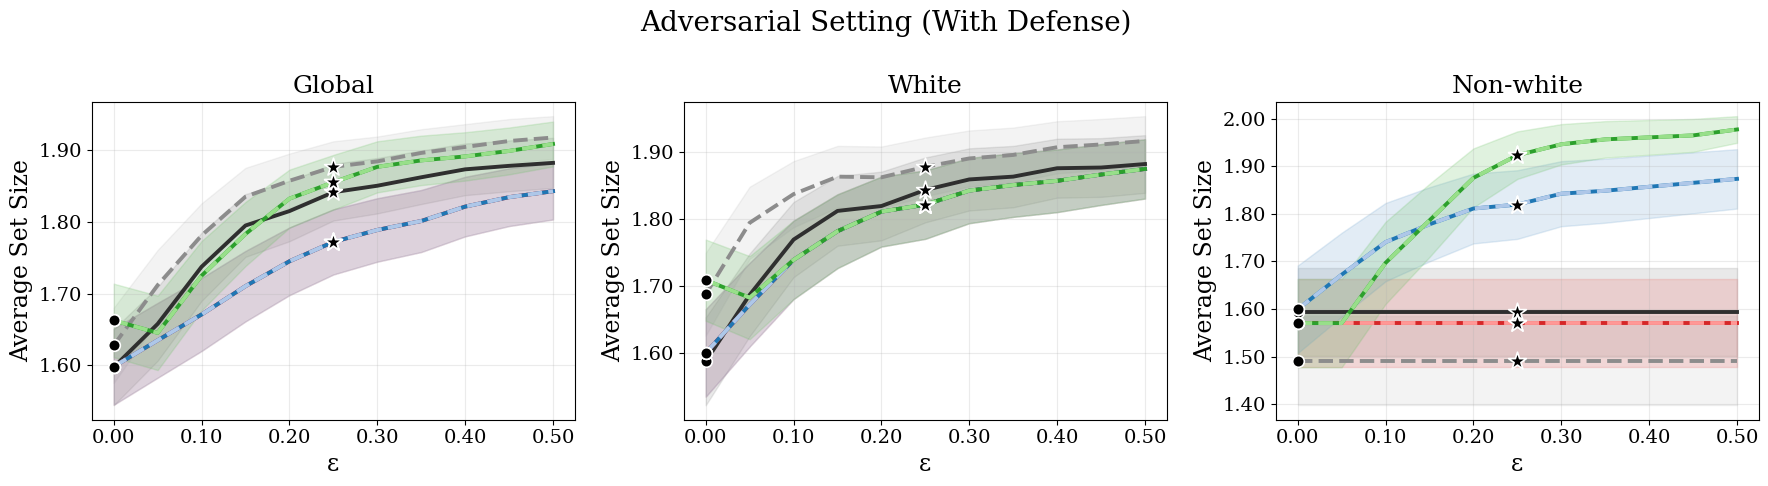

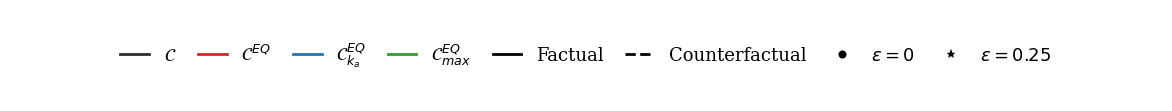

In [14]:
results_A2_0 = run_counterfactual_experiment_A2(model, dataset, eps_values, lambd=lambd, alpha=alpha, agg=agg, target_group = 0)

plot_cp_coverage(results_A2_0, 0.1, eps, dataset_name)
plot_cp_size(results_A2_0, 0.1, eps, dataset_name)
add_global_legend(eps)

100%|██████████| 11/11 [00:14<00:00,  1.36s/it]


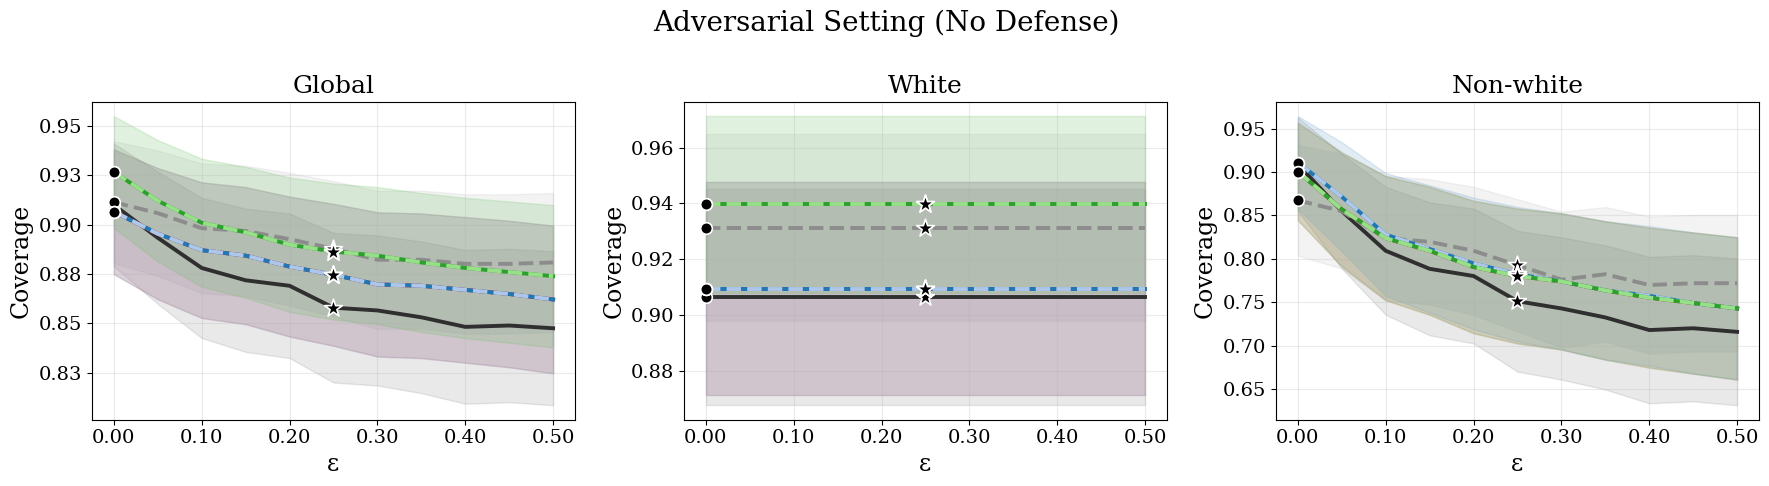

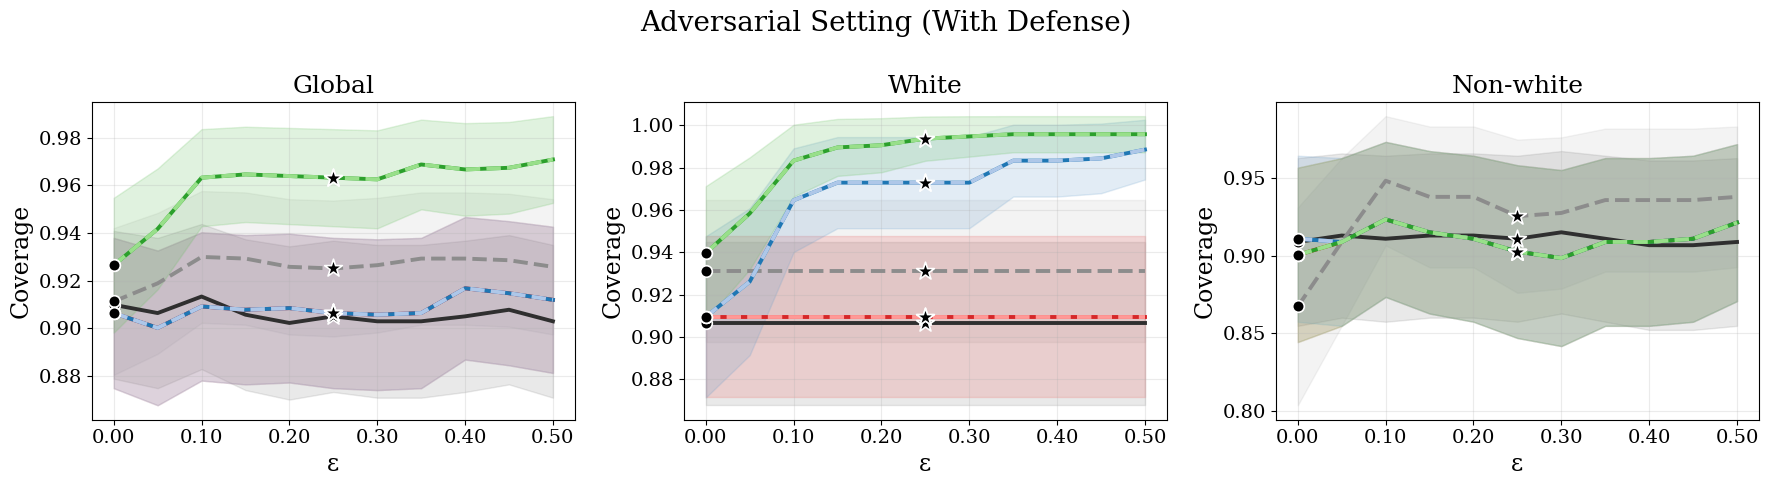

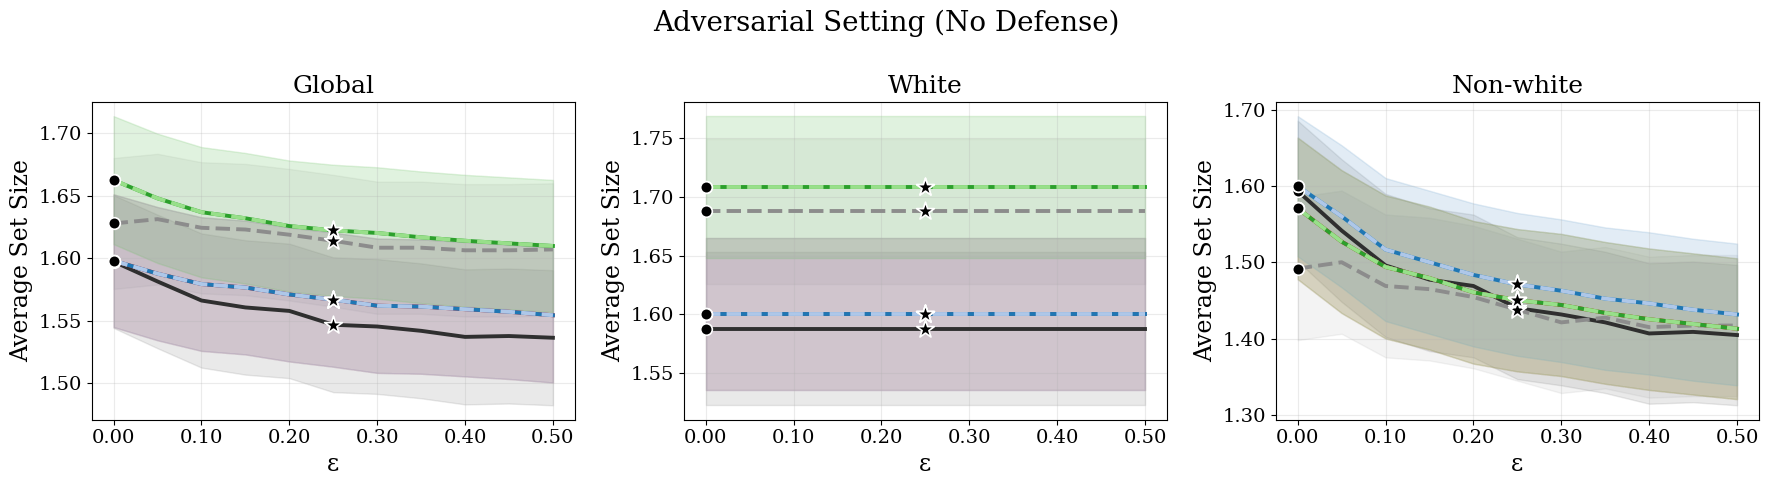

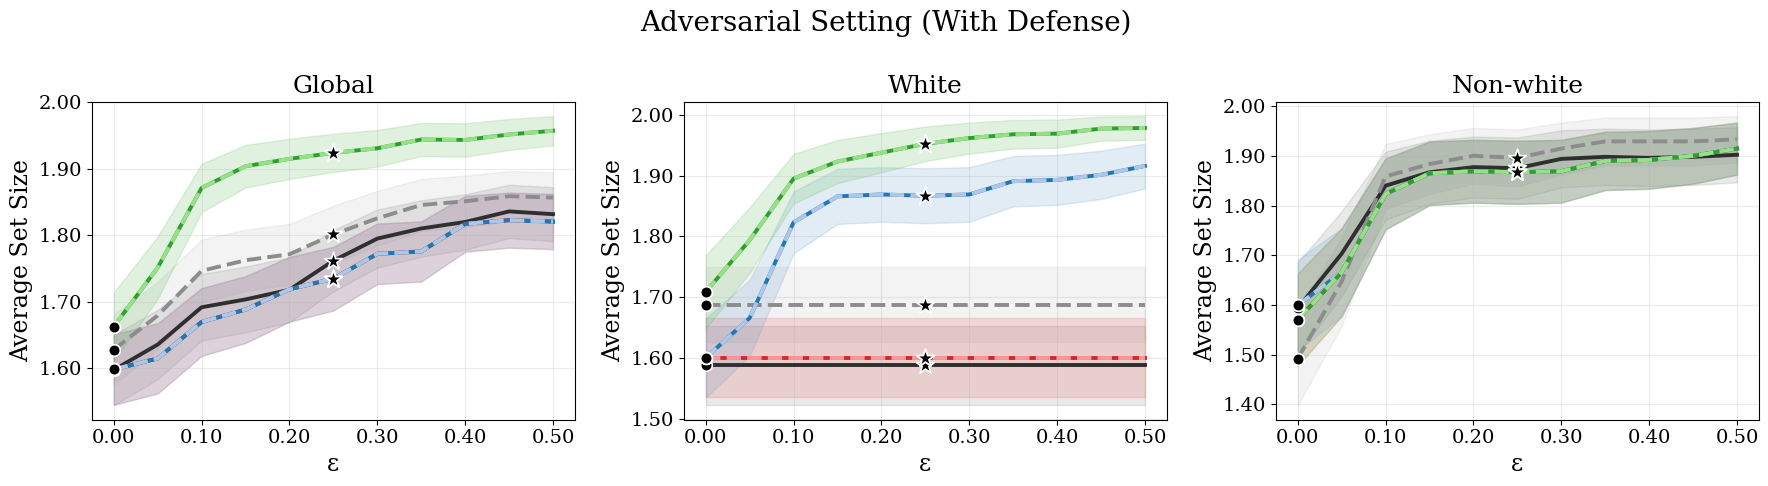

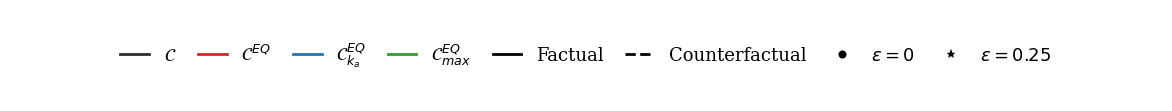

In [15]:
results_A2_1 = run_counterfactual_experiment_A2(model, dataset, eps_values, lambd=lambd, alpha=alpha, agg=agg, target_group = 1)

plot_cp_coverage(results_A2_1, 0.1, eps, dataset_name)
plot_cp_size(results_A2_1, 0.1, eps, dataset_name)
add_global_legend(eps)